In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, re, time
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords
from nltk.stem  import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression, SGDClassifier, PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Load Dataset

In [2]:
df = pd.read_csv('IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 63.6 MB


In [4]:
print('Shape:', df.shape)
print(df['sentiment'].value_counts())

Shape: (50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


# Preprocessing

In [5]:
STOP_WORDS  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOP_WORDS]
    return ' '.join(tokens)

In [6]:
df['review'] = df['review'].apply(preprocess)
df['sentiment'] = (df['sentiment'] == 'positive').astype(int)
df.head()

,review,sentiment
0,one reviewer mentioned watching oz episode you...,1
1,wonderful little production filming technique ...,1
2,thought wonderful way spend time hot summer we...,1
3,basically there family little boy jake think t...,0
4,petter matteis love time money visually stunni...,1


# Train/Test Split

In [7]:
x = df['review']
y = df['sentiment']

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f'Train: {len(x_train):,}  |  Test: {len(x_test):,}')

Train: 40,000  |  Test: 10,000


# Feature Extraction (BoW + TF-IDF)

In [9]:
bow  = CountVectorizer(max_features=30_000, ngram_range=(1, 2))
x_train_bow = bow.fit_transform(x_train)
x_test_bow = bow.transform(x_test)

tfidf = TfidfVectorizer(max_features=30_000, ngram_range=(1, 2))
x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

print(f"Bow matrix: {x_train_bow.shape}")
print(f"TF-IDF matrix: {x_train_tfidf.shape}")

Bow matrix: (40000, 30000)
TF-IDF matrix: (40000, 30000)


#  Train & Evaluate

In [10]:
classifiers = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, C=1.0),'tfidf'),
    ('Linear SVC', LinearSVC(max_iter=2000),'tfidf'),
    ('SGD Classifier', SGDClassifier(max_iter=100, loss='hinge'),'tfidf'),
    ('Passive Aggressive', PassiveAggressiveClassifier(max_iter=100), 'tfidf'),
    ('Multinomial Naive Bayes', MultinomialNB(alpha=0.1), 'bow'),
    ('Bernoulli Naive Bayes',  BernoulliNB(alpha=0.1), 'bow'),
    ('Decision Tree', DecisionTreeClassifier(max_depth=20), 'tfidf'),
    ('Random Forest', RandomForestClassifier(n_estimators=100, n_jobs=-1), 'tfidf'),
    ('Gradient Boosting', GradientBoostingClassifier(n_estimators=100), 'tfidf'),
    ('K-Nearest Neighbors', KNeighborsClassifier(n_neighbors=5), 'tfidf')
]

In [11]:
results = []

for name, model, feat in classifiers:
    xtr = x_train_tfidf if feat == 'tfidf' else x_train_bow
    xte = x_test_tfidf if feat == 'tfidf' else x_test_bow
    
    t0 = time.time()
    model.fit(xtr, y_train)
    pred = model.predict(xte)
    elapsed = time.time() - t0
    
    acc = accuracy_score(y_test, pred)
    rep = classification_report(y_test, pred, output_dict=True)
    results.append({
        'Model': name,
        'Features': feat.upper(),
        'Accuracy': round(acc * 100, 2),
        'Precision': round(rep['weighted avg']['precision'] * 100, 2),
        'Recall': round(rep['weighted avg']['recall'] * 100, 2),
        'F1-Score': round(rep['weighted avg']['f1-score'] * 100, 2),
        'Time(s)': round(elapsed, 1),
        '_pred': pred,
        '_model': model
	})
    
    print(f'{name:<30}  Acc={acc*100:.2f}%  ({elapsed:.1f}s)')

Logistic Regression             Acc=89.68%  (0.6s)
Linear SVC                      Acc=90.09%  (1.4s)
SGD Classifier                  Acc=89.81%  (0.3s)
Passive Aggressive              Acc=88.13%  (0.4s)
Multinomial Naive Bayes         Acc=86.90%  (0.0s)
Bernoulli Naive Bayes           Acc=87.35%  (0.1s)
Decision Tree                   Acc=74.19%  (23.4s)
Random Forest                   Acc=85.92%  (19.2s)
Gradient Boosting               Acc=81.02%  (136.7s)
K-Nearest Neighbors             Acc=77.18%  (8.2s)


#  Comparison Table

In [12]:
cols = ['Model','Features','Accuracy','Precision','Recall','F1-Score','Time(s)']
df_results = pd.DataFrame(results)[cols].sort_values('Accuracy', ascending=False)
df_results = df_results.reset_index(drop=True)
df_results.index += 1

df_results.style.background_gradient(subset=['Accuracy'], cmap='RdYlGn')

,Model,Features,Accuracy,Precision,Recall,F1-Score,Time(s)
1,Linear SVC,TFIDF,90.090000,90.100000,90.090000,90.090000,1.400000
2,SGD Classifier,TFIDF,89.810000,89.840000,89.810000,89.810000,0.300000
3,Logistic Regression,TFIDF,89.680000,89.700000,89.680000,89.680000,0.600000
4,Passive Aggressive,TFIDF,88.130000,88.130000,88.130000,88.130000,0.400000
5,Bernoulli Naive Bayes,BOW,87.350000,87.360000,87.350000,87.350000,0.100000
6,Multinomial Naive Bayes,BOW,86.900000,86.900000,86.900000,86.900000,0.000000
7,Random Forest,TFIDF,85.920000,85.940000,85.920000,85.920000,19.200000
8,Gradient Boosting,TFIDF,81.020000,81.330000,81.020000,80.960000,136.700000
9,K-Nearest Neighbors,TFIDF,77.180000,77.720000,77.180000,77.050000,8.200000
10,Decision Tree,TFIDF,74.190000,74.650000,74.190000,74.050000,23.400000


In [13]:
best  = df_results.iloc[0]['Model']
worst = df_results.iloc[-1]['Model']
print(f'Best  model: {best}')
print(f'Worst model: {worst}\n')

Best  model: Linear SVC
Worst model: Decision Tree



# Bar Chart — Model Accuracy 

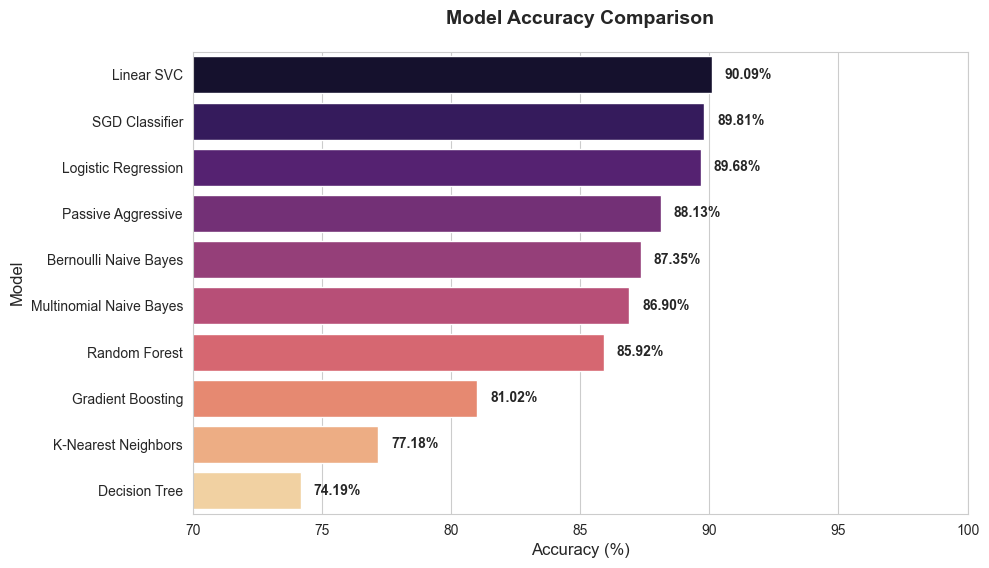

In [14]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x='Accuracy', y='Model', data=df_results, palette='magma')

plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Accuracy (%)', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xlim(70, 100)

for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.5, p.get_y() + p.get_height()/2, f'{width:.2f}%', 
             va='center', fontsize=10, fontweight='bold')

plt.show()

# Confusion Matrices

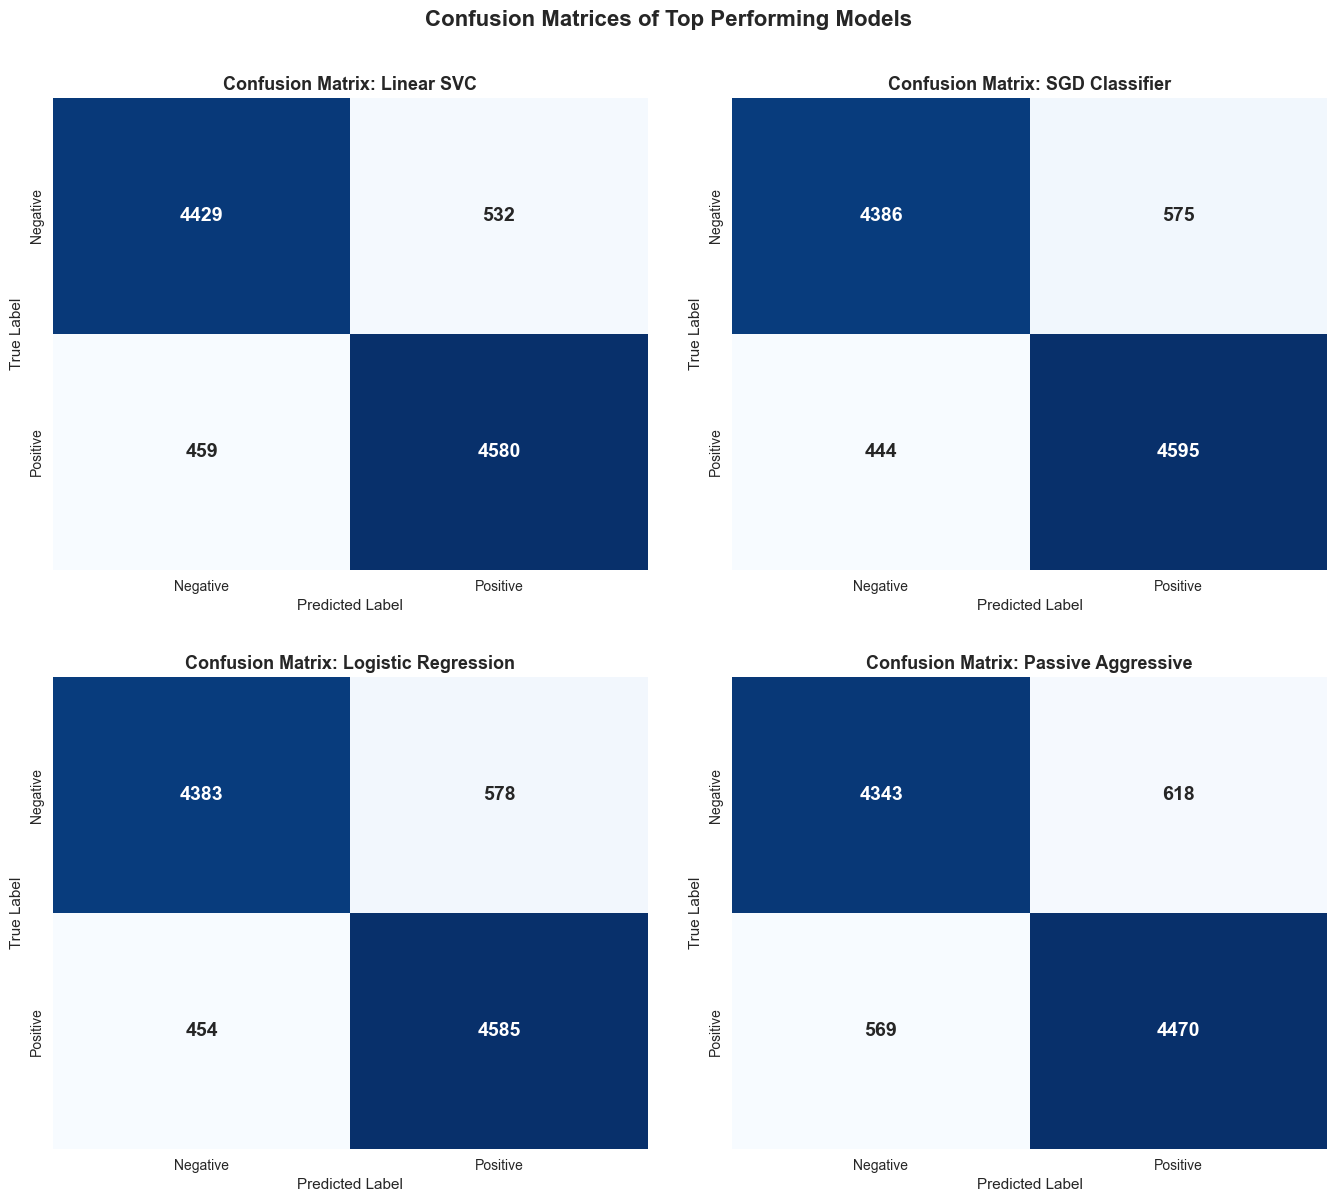

In [15]:
top_4_models = df_results.head(4)['Model'].tolist()
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, model_name in enumerate(top_4_models):
    res = next(r for r in results if r['Model'] == model_name)
    cm = confusion_matrix(y_test, res['_pred'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], 
                cbar=False, annot_kws={"size": 14, "weight": "bold"})
    
    axes[i].set_title(f'Confusion Matrix: {model_name}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Predicted Label', fontsize=11)
    axes[i].set_ylabel('True Label', fontsize=11)
    axes[i].set_xticklabels(['Negative', 'Positive'])
    axes[i].set_yticklabels(['Negative', 'Positive'])

plt.tight_layout(pad=3.0)
plt.suptitle('Confusion Matrices of Top Performing Models', fontsize=16, fontweight='bold', y=1.02)
plt.show()

# Precision / Recall / F1-Score Multi-metric Bar

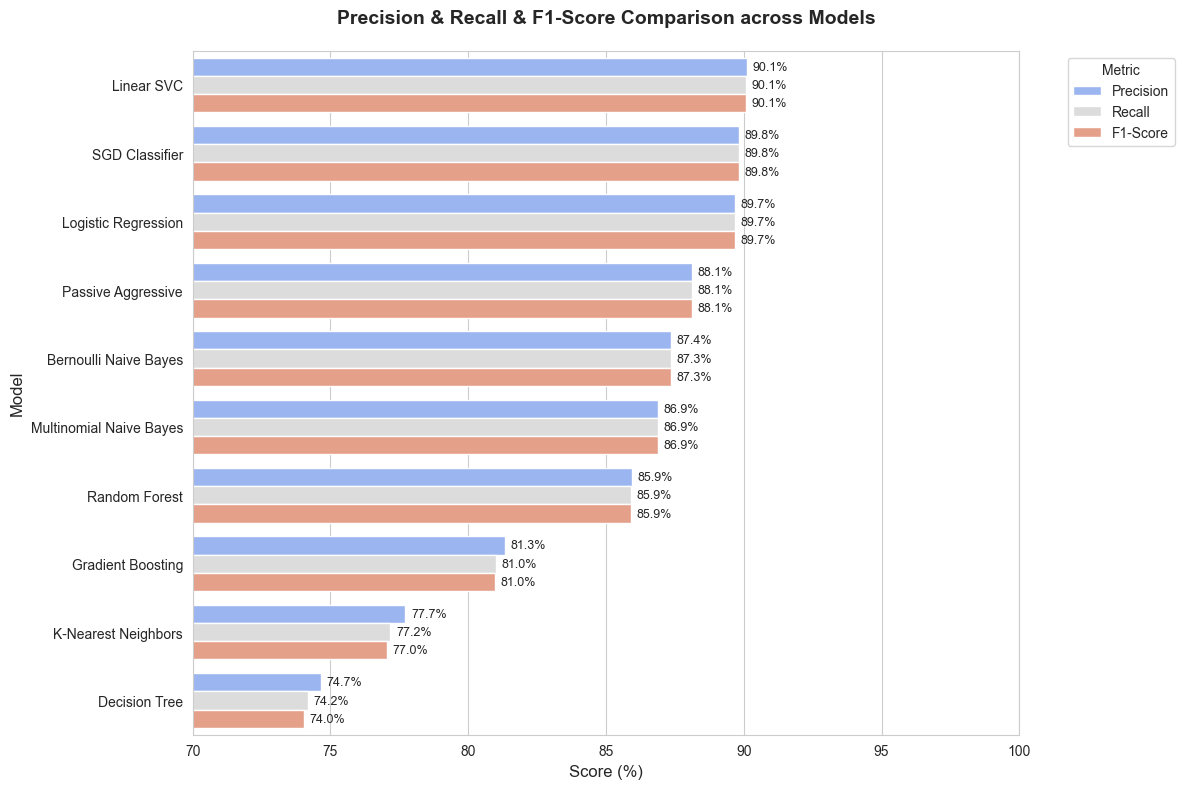

In [16]:
df_metrics = df_results.melt(id_vars='Model', value_vars=['Precision', 'Recall', 'F1-Score'], 
                             var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")
ax = sns.barplot(x='Score', y='Model', hue='Metric', data=df_metrics, palette='coolwarm')

plt.title('Precision & Recall & F1-Score Comparison across Models', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Score (%)', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xlim(70, 100)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        plt.text(width + 0.2, p.get_y() + p.get_height()/2, f'{width:.1f}%', 
                 va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Word2Vec Embeddings

In [17]:
from gensim.models import Word2Vec

train_tokens = [text.split() for text in x_train]
test_tokens  = [text.split() for text in x_test]

w2v = Word2Vec(
    sentences= train_tokens,
    vector_size= 100,
    window= 5,
    min_count= 3,
    workers= 4,
    epochs= 5,
    sg= 0
)

def doc_vector(tokens, model):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

x_train_w2v = np.array([doc_vector(t, w2v) for t in train_tokens])
x_test_w2v  = np.array([doc_vector(t, w2v) for t in test_tokens])

lr_w2v = LogisticRegression(max_iter=1000, C=1.0)
lr_w2v.fit(x_train_w2v, y_train)
preds_w2v = lr_w2v.predict(x_test_w2v)
acc_w2v   = accuracy_score(y_test, preds_w2v)

tfidf_acc = next(r['Accuracy'] for r in results if r['Model'] == 'Logistic Regression')

print(f'Logistic Regression + TF-IDF  : {tfidf_acc}%')
print(f'Logistic Regression + Word2Vec: {acc_w2v*100:.2f}%')

Logistic Regression + TF-IDF  : 89.68%
Logistic Regression + Word2Vec: 85.35%


#  Word2Vec — Most Similar Words (sanity check)

In [18]:
for word in ['good', 'bad', 'film', 'terrible']:
    try:
        similar = w2v.wv.most_similar(word, topn=5)
        words   = [w for w, _ in similar]
        print(f'{word:10}: {words}')
    except KeyError:
        print(f'{word:10}: not in vocabulary')

good      : ['decent', 'great', 'bad', 'alright', 'fine']
bad       : ['terrible', 'awful', 'horrible', 'good', 'suck']
film      : ['movie', 'flick', 'documentary', 'picture', 'cinema']
terrible  : ['horrible', 'awful', 'atrocious', 'horrendous', 'lousy']
